## 2. Analisi offerte di lavoro

In [5]:
%conda install pandas
%conda install matplotlib
%conda install datasets

2 channel Terms of Service accepted
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.3.2
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.

CondaError: KeyboardInterrupt

^C

Note: you may need to restart the kernel to use updated packages.
2 channel Terms of Service accepted
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.3.2
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd 
import matplotlib.pyplot as plt
from datasets import load_dataset

In [7]:
# Carica il dataset
dataset = load_dataset('lukebarousse/data_jobs')

# Converte in un Dataframe Pandas
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df

Generating train split: 100%|██████████| 785741/785741 [00:06<00:00, 129580.30 examples/s]


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785736,Software Engineer,DevOps Engineer,Singapura,melalui Trabajo.org,Pekerjaan tetap,False,Singapore,2023-03-13 06:16:16,False,False,Singapore,NaN,NaN,NaN,CAREERSTAR INTERNATIONAL PTE. LTD.,"['bash', 'python', 'perl', 'linux', 'unix', 'k...","{'os': ['linux', 'unix'], 'other': ['kubernete..."
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,HABA FAMILYGROUP,"['sas', 'sas', 'sql', 'excel']","{'analyst_tools': ['sas', 'excel'], 'programmi..."
785738,Business Analyst,Commercial Analyst - Start Now,Malaysia,melalui Ricebowl,Pekerjaan tetap,False,Malaysia,2023-03-12 06:32:36,False,False,Malaysia,NaN,NaN,NaN,Lendlease Corporation,"['powerpoint', 'excel']","{'analyst_tools': ['powerpoint', 'excel']}"
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,NaN,NaN,NaN,Capital One,"['python', 'go', 'nosql', 'sql', 'mongo', 'she...","{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."


Esegui un’analisi esplorativa focalizzata sui lavori nel campo dei dati in ciascun paese.
Analizza i seguenti aspetti per ogni paese:

1. Lo stipendio medio annuale (salary_year_avg)
2. Il numero totale di offerte di lavoro (job count)
3. L’intervallo degli stipendi: valore minimo e massimo (min / max)

In [ ]:
# Elimino le righe con i dati assenti
df = df[df['salary_year_avg'].notna()]

In [32]:
df.groupby('job_country')['salary_year_avg'].agg(
    avg_salary='mean',
    job_count='count',
    min_salary='min',
    max_salary='max'
).reset_index()

,job_country,avg_salary,job_count,min_salary,max_salary
0,Albania,79472.500000,5,43200.0,157500.0
1,Algeria,44550.000000,2,44100.0,45000.0
2,Argentina,105212.343750,32,45000.0,222000.0
3,Armenia,78757.000000,6,45000.0,128682.0
4,Australia,118987.574324,74,20000.0,257500.0
...,...,...,...,...,...
103,Uruguay,69333.333333,3,50000.0,100500.0
104,Uzbekistan,30750.000000,1,30750.0,30750.0
105,Vietnam,90927.236364,55,28000.0,200000.0
106,Zambia,90670.000000,1,90670.0,90670.0


Rappresenta graficamente lo stipendio medio (salary_year_avg) per job_title_short usando un grafico a barre orizzontali. Ordina i dati dallo stipendio più alto al più basso. Includi un titolo e le etichette per gli assi x e y.

In [38]:
# Creo un dataframe con i lavori e i relativi salari medi
avg_salary_per_job = df.groupby('job_title_short')['salary_year_avg'].agg(
    avg_salary='mean'
).reset_index()

avg_salary_per_job

,job_title_short,avg_salary
0,Business Analyst,91082.612833
1,Cloud Engineer,111268.453846
2,Data Analyst,93841.907854
3,Data Engineer,130125.604250
4,Data Scientist,135988.837171
5,Machine Learning Engineer,126774.315972
6,Senior Data Analyst,113911.363665
7,Senior Data Engineer,145840.611624
8,Senior Data Scientist,154206.292996
9,Software Engineer,113393.760054


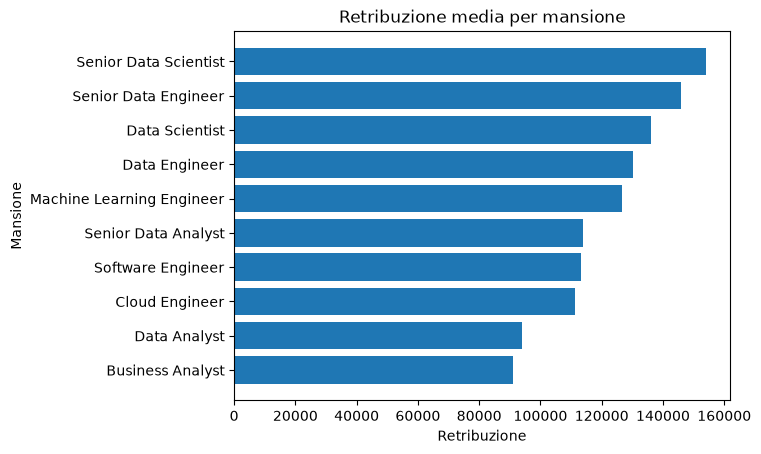

In [39]:
# Ordino i lavori per salario medio dal più alto al più basso
avg_salary_per_job = avg_salary_per_job.sort_values('avg_salary')

plt.barh(avg_salary_per_job['job_title_short'], avg_salary_per_job['avg_salary'])
plt.title('Retribuzione media per mansione')
plt.ylabel('Mansione')
plt.xlabel('Retribuzione')
plt.show()